In [ ]:
!pip install shap -q

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.classification import DecisionTreeClassificationModel
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.classification import LinearSVCModel

from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.sql import Row
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import shap
import numpy as np
import matplotlib.pyplot as plt

# Creating Spark Session

In [ ]:
spark = SparkSession.builder \
    .appName("AmazonReviews_Task5") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.3


# Loading Prediction Files

In [ ]:
# Models
lr_model = LogisticRegressionModel.load("lr_model")
dt_model = DecisionTreeClassificationModel.load("dt_model")
rf_model = RandomForestClassificationModel.load("rf_model")
svm_model = LinearSVCModel.load("svm_model")

# Predictions
lr_predictions = spark.read.parquet("lr_predictions")
dt_predictions = spark.read.parquet("dt_predictions")
rf_predictions = spark.read.parquet("rf_predictions")
svm_predictions = spark.read.parquet("svm_predictions")

# Comparison Results
results_df = spark.read.csv(
    "model_comparison_results",
    header=True,
    inferSchema=True
)

print("Everything loaded successfully.")

Everything loaded successfully.


# Logistic Regression Confusion Matrix

In [ ]:
lr_predictions.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       0.0|    750|
|    0|       1.0| 331966|
|    1|       0.0|   1199|
|    1|       1.0|1866634|
+-----+----------+-------+



# Decision Tree Confusion Matrix

In [ ]:
dt_predictions.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       1.0| 332716|
|    1|       1.0|1867833|
+-----+----------+-------+



# Random Forest Confusion Matrix

In [ ]:
rf_predictions.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       1.0| 332716|
|    1|       1.0|1867833|
+-----+----------+-------+



# Linear SVM Confusion Matrix

In [ ]:
svm_predictions.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       1.0| 332716|
|    1|       1.0|1867833|
+-----+----------+-------+



# Logistic Regression ROC Curve

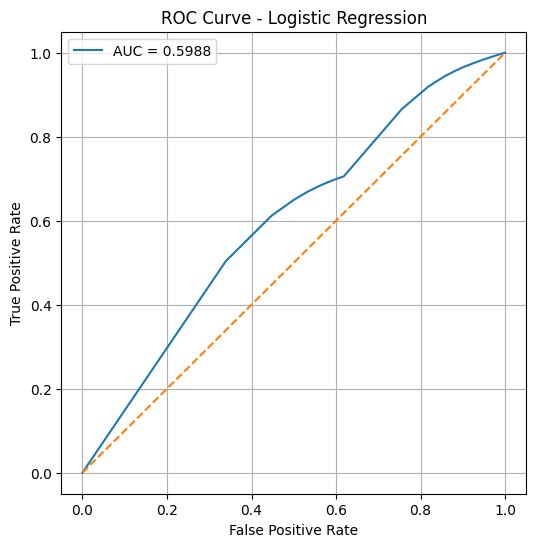

In [ ]:
lr_pdf = lr_predictions.select("label", "probability").toPandas()

y_true = lr_pdf["label"]
y_score = lr_pdf["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# Decision Tree ROC Curve

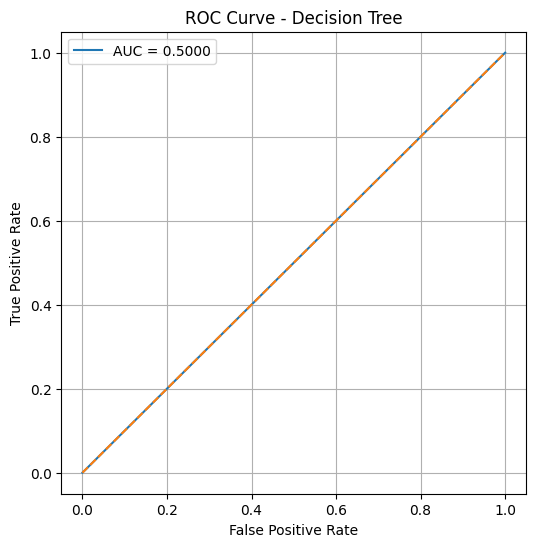

In [ ]:
dt_pdf = dt_predictions.select("label", "probability").toPandas()

y_true = dt_pdf["label"]
y_score = dt_pdf["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

# Random Forest ROC Curve

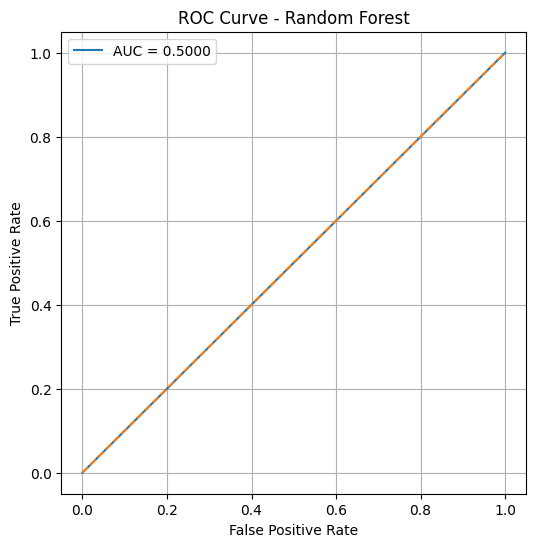

In [ ]:
rf_pdf = rf_predictions.select("label", "probability").toPandas()

y_true = rf_pdf["label"]
y_score = rf_pdf["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# Linear SVM ROC Curve

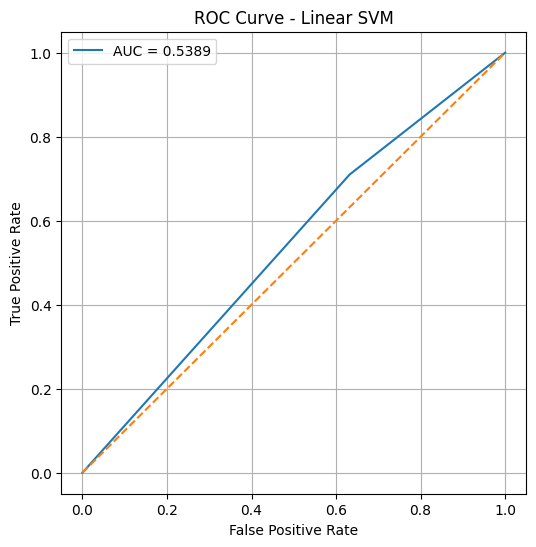

In [ ]:
svm_pdf = svm_predictions.select("label", "rawPrediction").toPandas()

y_true = svm_pdf["label"]
y_score = svm_pdf["rawPrediction"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

# Logistic Regression Precision-Recall Curve

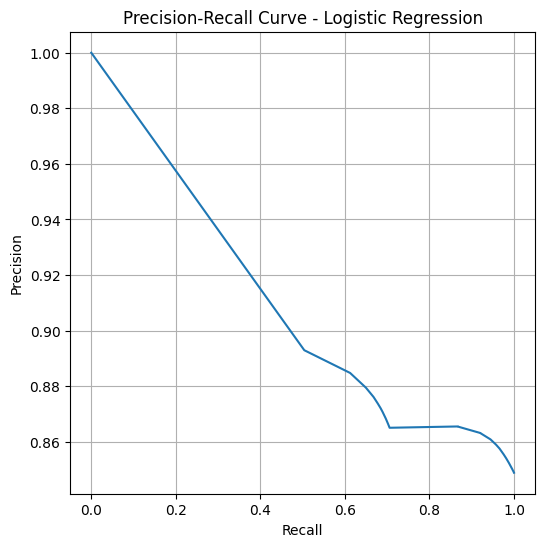

In [ ]:
precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.grid(True)
plt.show()

# Decision Tree Precision-Recall Curve

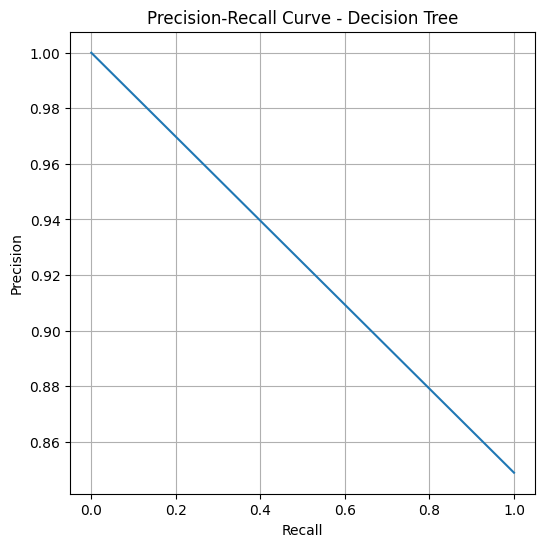

In [ ]:
precision, recall, _ = precision_recall_curve(
    dt_pdf["label"],
    dt_pdf["probability"].apply(lambda x: float(x[1]))
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Decision Tree")
plt.grid(True)
plt.show()

# Random Forest Precision-Recall Curve

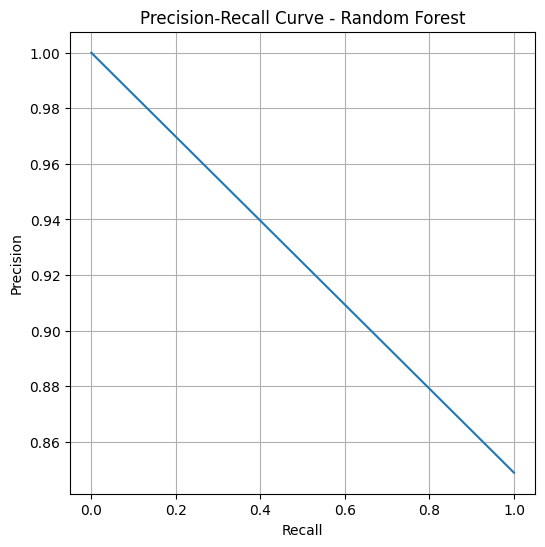

In [ ]:
precision, recall, _ = precision_recall_curve(
    rf_pdf["label"],
    rf_pdf["probability"].apply(lambda x: float(x[1]))
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.grid(True)
plt.show()

# Linear SVM Precision-Recall Curve

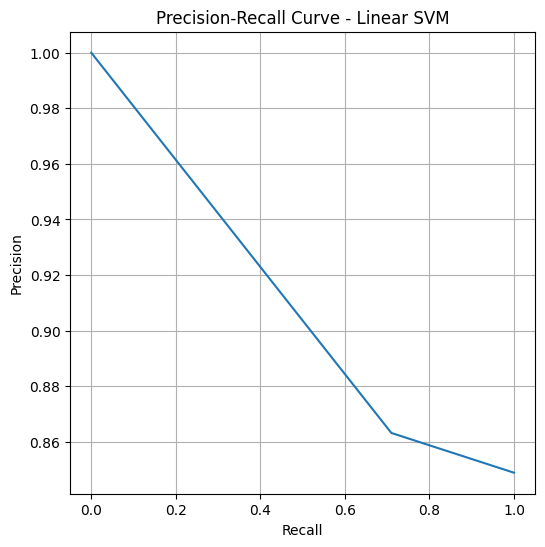

In [ ]:
precision, recall, _ = precision_recall_curve(
    svm_pdf["label"],
    svm_pdf["rawPrediction"].apply(lambda x: float(x[1]))
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Linear SVM")
plt.grid(True)
plt.show()

# Creating a Sample of the Prediction Data

In [ ]:
lr_stability = lr_predictions.sample(
    withReplacement=False,
    fraction=0.80,
    seed=42
)

dt_stability = dt_predictions.sample(
    withReplacement=False,
    fraction=0.80,
    seed=42
)

rf_stability = rf_predictions.sample(
    withReplacement=False,
    fraction=0.80,
    seed=42
)

svm_stability = svm_predictions.sample(
    withReplacement=False,
    fraction=0.80,
    seed=42
)

# Evaluating the Sampled Predictions

In [ ]:
def evaluate(predictions):

    accuracy = accuracyEvaluator.evaluate(predictions)
    precision = precisionEvaluator.evaluate(predictions)
    recall = recallEvaluator.evaluate(predictions)
    f1 = f1Evaluator.evaluate(predictions)
    auc = aucEvaluator.evaluate(predictions)

    return accuracy, precision, recall, f1, auc

# Evaluating All Models

In [ ]:
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

accuracyEvaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

precisionEvaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recallEvaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1Evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

aucEvaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [ ]:
lr_results = evaluate(lr_stability)

dt_results = evaluate(dt_stability)

rf_results = evaluate(rf_stability)

svm_results = evaluate(svm_stability)

# Displaying Stability Results

In [ ]:
from pyspark.sql import Row

stability_results = [

    Row(
        Model="Logistic Regression",
        Accuracy=lr_results[0],
        Precision=lr_results[1],
        Recall=lr_results[2],
        F1=lr_results[3],
        AUC=lr_results[4]
    ),

    Row(
        Model="Decision Tree",
        Accuracy=dt_results[0],
        Precision=dt_results[1],
        Recall=dt_results[2],
        F1=dt_results[3],
        AUC=dt_results[4]
    ),

    Row(
        Model="Random Forest",
        Accuracy=rf_results[0],
        Precision=rf_results[1],
        Recall=rf_results[2],
        F1=rf_results[3],
        AUC=rf_results[4]
    ),

    Row(
        Model="Linear SVM",
        Accuracy=svm_results[0],
        Precision=svm_results[1],
        Recall=svm_results[2],
        F1=svm_results[3],
        AUC=svm_results[4]
    )

]

stability_df = spark.createDataFrame(stability_results)

stability_df.show(truncate=False)

+-------------------+------------------+------------------+------------------+------------------+------------------+
|Model              |Accuracy          |Precision         |Recall            |F1                |AUC               |
+-------------------+------------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.8485902276453142|0.7796168342988152|0.8485902276453142|0.7799124746348389|0.5989449063639116|
|Decision Tree      |0.8487815930345269|0.7204301926742294|0.8487815930345269|0.7793567346067524|0.5               |
|Random Forest      |0.8487815930345269|0.7204301926742294|0.8487815930345269|0.7793567346067524|0.5               |
|Linear SVM         |0.8487815930345269|0.7204301926742294|0.8487815930345269|0.7793567346067524|0.5387960581705417|
+-------------------+------------------+------------------+------------------+------------------+------------------+



# SHAP

In [ ]:
sample = lr_predictions.select("features", "label").limit(500).toPandas()

X = np.array(sample["features"].tolist())

y = sample["label"]

In [ ]:
coef = np.array(lr_model.coefficients)

intercept = lr_model.intercept

In [ ]:
explainer = shap.LinearExplainer(
    (coef, intercept),
    X
)

shap_values = explainer.shap_values(X)

# SHAP Waterfall Plot

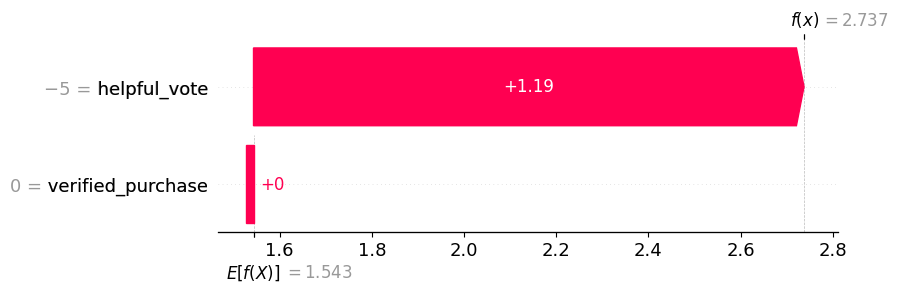

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X[0],
        feature_names=["helpful_vote", "verified_purchase"]
    )
)

# Converting Parquet files to CSV

In [ ]:
df = spark.read.parquet("amazon_reviews_clean_11M")

In [ ]:
print("Rows:", df.count())

df.printSchema()

df.show(5, truncate=False)

Rows: 11000000
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+----------+------------+------+-----------+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
df_csv = df.drop("images")

In [ ]:
from pyspark.sql import functions as F

df_tableau = df_csv.orderBy(F.rand(seed=42)).limit(250000)

df_tableau.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("tableau_dataset")